# SVD and PCA for Dimensionality Reduction

AIT 525 assignment on the International Graduates Employment dataset.

## Part 1: Dataset Selection

This dataset, sourced from Kaggle ("International Graduates Employment Dataset" by quackquackrp), combines a record of anonymized international graduates and their outcomes after obtaining their degree. It is built from real survey data, including the UK HESA Graduate Outcomes Survey and the EU Labour Force Survey. The dataset contains 300,000 rows and 15 columns, with key features including Education_Level, Field_of_Study, Employment_Status, Salary, GPA, Age, and Years_Since_Graduation, along with additional details like Country_of_Origin, Visa_Type, and Language_Proficiency. The goal is to use predictive analysis to determine things like employment status, salary estimation, and feature analysis based on these graduates' academic and demographic backgrounds.

### Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("graduates_data/international_graduates_employment.csv")
print(df.shape)
df.head()

(300000, 15)


,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector
0,Vietnam,Bachelor's,IT,Fluent,Permanent Residency,Female,Low,EU,23,8,3.76,Yes,Employed,54397,Healthcare
1,Germany,Master's,Arts,Intermediate,Post-study,Male,High,UK,38,9,3.76,No,Employed,69635,Finance
2,Brazil,PhD,Engineering,Intermediate,Post-study,Male,High,Canada,23,2,3.52,Yes,Employed,96216,Finance
3,Vietnam,PhD,Health,Fluent,Post-study,Female,Medium,Australia,25,5,3.28,Yes,Employed,86076,Other
4,Nigeria,PhD,Engineering,Basic,Student,Male,High,Canada,24,2,3.01,Yes,Employed,82772,Finance


In [2]:
numeric_columns = ['Age','Years_Since_Graduation','GPA','Salary']
X = df[numeric_columns]
print(X)

        Age  Years_Since_Graduation   GPA  Salary
0        23                       8  3.76   54397
1        38                       9  3.76   69635
2        23                       2  3.52   96216
3        25                       5  3.28   86076
4        24                       2  3.01   82772
...     ...                     ...   ...     ...
299995   29                       7  3.12       0
299996   22                       6  3.01   33632
299997   31                       3  3.48   87523
299998   37                       2  3.21       0
299999   34                       3  3.03   37734

[300000 rows x 4 columns]


In [3]:
df.columns

Index(['Country_of_Origin', 'Education_Level', 'Field_of_Study',
       'Language_Proficiency', 'Visa_Type', 'Gender', 'University_Ranking',
       'Region_of_Study', 'Age', 'Years_Since_Graduation', 'GPA',
       'Internship_Experience', 'Employment_Status', 'Salary', 'Job_Sector'],
      dtype='str')

In [4]:
categorical_columns = ['Country_of_Origin', 'Education_Level', 'Field_of_Study',
       'Language_Proficiency', 'Visa_Type', 'Gender', 'University_Ranking',
       'Region_of_Study','Internship_Experience','Job_Sector']

encoded = pd.get_dummies(df[categorical_columns], dtype=int)
X = pd.concat([X, encoded], axis=1)
print(X)

        Age  Years_Since_Graduation   GPA  Salary  Country_of_Origin_Brazil  \
0        23                       8  3.76   54397                         0   
1        38                       9  3.76   69635                         0   
2        23                       2  3.52   96216                         1   
3        25                       5  3.28   86076                         0   
4        24                       2  3.01   82772                         0   
...     ...                     ...   ...     ...                       ...   
299995   29                       7  3.12       0                         0   
299996   22                       6  3.01   33632                         0   
299997   31                       3  3.48   87523                         0   
299998   37                       2  3.21       0                         0   
299999   34                       3  3.03   37734                         0   

        Country_of_Origin_China  Country_of_Origin_

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.44487926  1.21613731  1.39809336 ... -0.26522243 -0.26510002
  -0.26342533]
 [ 1.44644057  1.5640176   1.39809336 ... -0.26522243 -0.26510002
  -0.26342533]
 [-1.44487926 -0.87114443  0.79851966 ... -0.26522243 -0.26510002
  -0.26342533]
 ...
 [ 0.09715798 -0.52326414  0.69859071 ... -0.26522243 -0.26510002
  -0.26342533]
 [ 1.25368592 -0.87114443  0.0240703  ... -0.26522243 -0.26510002
  -0.26342533]
 [ 0.67542195 -0.52326414 -0.42560997 ... -0.26522243 -0.26510002
  -0.26342533]]


In [6]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
print(U.shape)
print(S.shape)
print(Vt.shape)


(300000, 50)
(50,)
(50, 50)


In [7]:
explained_variance_ratio = S**2 / np.sum(S**2)
cumulative_explained = np.cumsum(explained_variance_ratio)
print(explained_variance_ratio.shape)
print(cumulative_explained.shape)

(50,)
(50,)


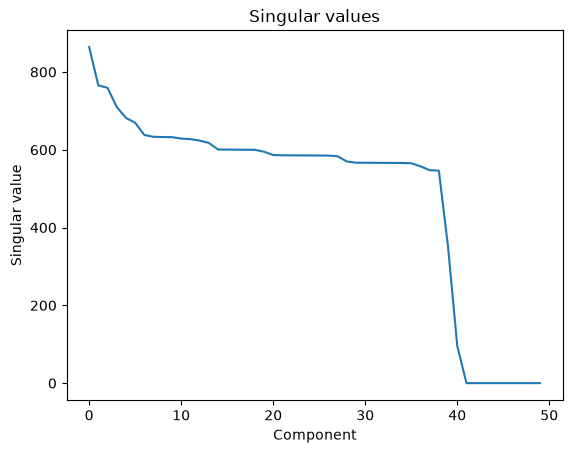

In [8]:
plt.plot(S)
plt.xlabel('Component')
plt.ylabel('Singular value')
plt.title('Singular values')
plt.show()

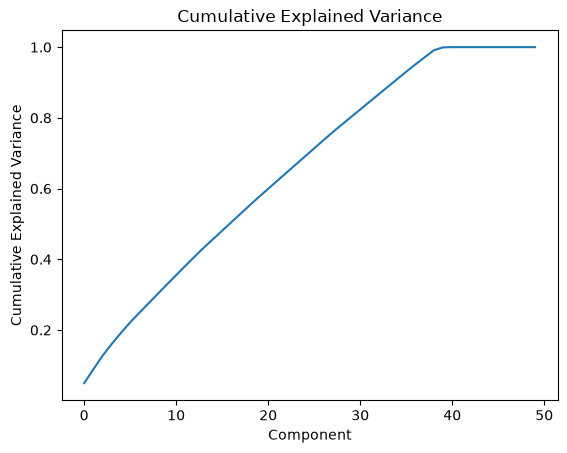

In [9]:
plt.plot(cumulative_explained)
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.show()